In [50]:
#!/usr/bin/env python
import matplotlib.pyplot as plt
import numpy as np
from lmfit.models import LorentzianModel, QuadraticModel, VoigtModel
import pandas as pd


def add_peak(prefix, center, amplitude=0.005, sigma=0.05):
    peak = VoigtModel(prefix=prefix)
    pars = peak.make_params()
    pars[prefix + 'center'].set(center)
    pars[prefix + 'amplitude'].set(amplitude, min = 0)
    pars[prefix + 'sigma'].set(sigma, min=0)
    return peak, pars



In [58]:
# Choose .csv data file and turn it into dataframe
colnames = ["wavenum" , "val"] #Defines the column tites for a csv without titles
# Edit the CSV Name here for your first file
file = pd.read_csv('FTIR_240713_PtAL2O3_overKBr_CO_100ppm_CO40min.csv', names = colnames) #,header=[0,1]) 
drifts_df = pd.DataFrame(file)
#This works for the CSV that is exported from the OMNIC software, where Wavenumber is the first column and the Units are the second column
#All CSVs imported together must have the same Wavenumber range! (Future code will be able to handle data with different ranges]
wavenum = drifts_df.iloc[:, 0]
#This step adds all the Data name, the data, and whether you want it to be included in the current plot with a true false statement. 
#This info is added as a list to a large list that compiles all your data
#The data name is used as the legend name for the data
datalist = [["300C",drifts_df.iloc[:, 1], True]]
#Change true to false for any one you want to exclude from a given plot.
wn1 = 1700 # Start in wn
wn2= 2200 # End in wn
#Finds the location of that wavenumber in the index
wn1_df = wavenum.iloc[(wavenum-wn1).abs().argsort()[:1]].index[0]
wn2_df = wavenum.iloc[(wavenum-wn2).abs().argsort()[:1]].index[0] 
print(wn1_df)
print(wn2_df)
xdat = wavenum.iloc[wn1_df:wn2_df]
ydat = datalist[0][1].iloc[wn1_df:wn2_df]
print(xdat)
print(ydat)

1089
1608
1089    1699.971
1090    1700.936
1091    1701.900
1092    1702.864
1093    1703.828
          ...   
1603    2195.595
1604    2196.560
1605    2197.524
1606    2198.488
1607    2199.452
Name: wavenum, Length: 519, dtype: float64
1089   -0.033382
1090   -0.033148
1091   -0.032856
1092   -0.032535
1093   -0.032227
          ...   
1603   -0.036060
1604   -0.036104
1605   -0.036154
1606   -0.036204
1607   -0.036249
Name: val, Length: 519, dtype: float64


In [59]:
model = QuadraticModel(prefix='bkg_')
params = model.make_params(a=0, b=0, c=0)

rough_peak_positions = (2050,2000,1980,1975)
for i, cen in enumerate(rough_peak_positions):
    peak, pars = add_peak('lz%d_' % (i+1), cen)
    model = model + peak
    params.update(pars)

init = model.eval(params, x=xdat)
result = model.fit(ydat, params, x=xdat)
comps = result.eval_components()

print(result.fit_report(min_correl=0.5))


[[Model]]
    ((((Model(parabolic, prefix='bkg_') + Model(voigt, prefix='lz1_')) + Model(voigt, prefix='lz2_')) + Model(voigt, prefix='lz3_')) + Model(voigt, prefix='lz4_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 32000
    # data points      = 519
    # variables        = 15
    chi-square         = 1.9928e-04
    reduced chi-square = 3.9539e-07
    Akaike info crit   = -7637.04594
    Bayesian info crit = -7573.26738
    R-squared          = 0.98828988
##  Warning: uncertainties could not be estimated:
[[Variables]]
    bkg_a:          1.1799e-08 (init = 0)
    bkg_b:         -5.2591e-05 (init = 0)
    bkg_c:          0.02126486 (init = 0)
    lz1_amplitude:  0.49019267 (init = 0.005)
    lz1_center:     2055.57479 (init = 2050)
    lz1_sigma:      6.23884936 (init = 0.05)
    lz1_gamma:      6.23884936 == 'lz1_sigma'
    lz1_fwhm:       22.4679098 == '1.0692*lz1_gamma+sqrt(0.8664*lz1_gamma**2+5.545083*lz1_sigma**2)'
    lz1_height:     0.01639850

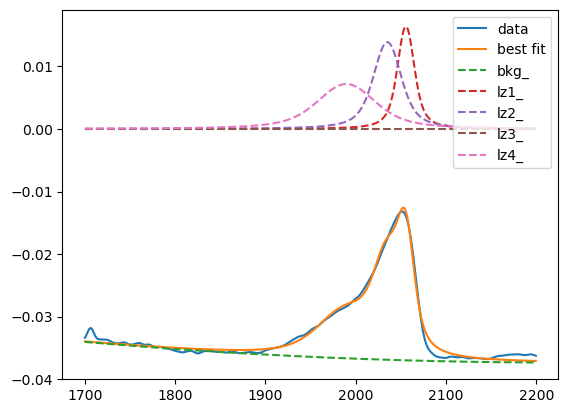

In [60]:
plt.plot(xdat, ydat, label='data')
plt.plot(xdat, result.best_fit, label='best fit')
for name, comp in comps.items():
    plt.plot(xdat, comp, '--', label=name)
plt.legend(loc='upper right')
plt.show()